# Worksheet: Least square problem

Consider the following least-square problem

$$ \mathop{ \mathrm{min} }_x \|Ax-b\|_2^2, $$

the solution can be written as a nice formula $x=(A^TA)^{-1}A^Tb$, which comes from normal equation $A^TAx = A^Tb$.

**The goal of this worksheet is comparing computational times of matrix inversion method `solve` method.**

In this part, we want to compare the computational times of using matrix inversion formula and `solve` method.

Step 1: Generate $A\in R^{m\times N}$ and $b \in R^{N \times 1}$ using `np.random.randn` with fixed number of rows $m=1000$ and varied number of columns $N=[1000,2000,4000,8000]$  Then, use matrix inversion formula and solve method to solve least square problem with $A$ and $b$.

Step 2: Visualization. 1) The first plot (Figure 1) is log(time) (y-axis) vs log(N) (x-axis). Do not use `log-log` method in matpotlib, compute log(time) and log(N) on your own and visualize them. 2) Figure 2: use `log-log` method in matplotlib to visualize log(time) (y-axis) vs log(N) (x-axis).

Step 3: Conclusion. 1) Computing log-log plot and `log-log` method. What are the differences between Figure 1 and Figure 2. (P.S. Answer this question by comparing two figures. They are equivalent on the theoreticla side.) 2) Write down your comments about computional times. 


#### Submission guidelines:

1. Please **restart the kernel and run all** before you submit. 
2. Render the notebook to a pdf file (menu bar: file -> print preview -> save as pdf).
3. Submit the pdf version to Gradescope. Make sure that all of your code and results show properly in the pdf file.

#### Grading policiy:

1. **Visualization** You should use subplot to present your plot in parallel. Adding labels, titles, legends, and etc to make your plot informative. 

2. **Conclusion** Your conclusins should be relevant and correct.


#### Bonus

This is not a true bonus question because of no extra credits. 

If you know the convergence rates. Could you numerically verify the convergence rate of `matrix inversion` and `solve` method.

In [2]:
import numpy as np
import time

m = 5000
N_range = [200, 400, 800, 1600, 3200]

time_inverse = []
time_solve = []

for N in N_range:
    A = np.random.randn(m,N)
    b = np.random.randn(m,1)
    
    # inverse
    start = time.time()
    x = np.linalg.inv(A.T @ A) @ A.T @ b
    stop = time.time()
    time_inverse.append(stop-start)
    
    # solve
    start = time.time()
    x = np.linalg.solve(A.T @ A, A.T @ b)
    stop = time.time()
    time_solve.append(stop-start)
    

Text(0.5, 1.0, 'Log-log plot')

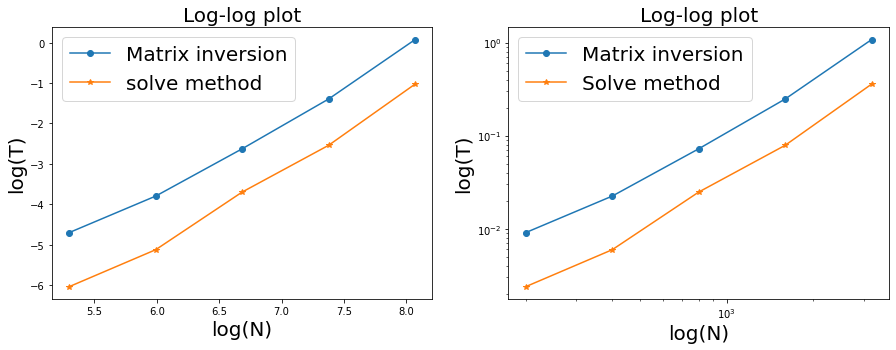

In [11]:
import matplotlib.pyplot as plt

fig, [ax1, ax2] = plt.subplots(1,2, figsize=(15,5))

ax1.plot(np.log(N_range), np.log(time_inverse), '-o', label='Matrix inversion')
ax1.plot(np.log(N_range), np.log(time_solve), '-*', label = "solve method")
ax1.legend(fontsize=20)
ax1.set_xlabel('log(N)', fontsize=20)
ax1.set_ylabel('log(T)', fontsize=20)
ax1.set_title("Log-log plot", fontsize=20)

ax2.loglog(N_range, time_inverse, '-o', label='Matrix inversion')
ax2.loglog(N_range, time_solve, '-*', label = "Solve method")
ax2.legend(fontsize=20)
ax2.set_xlabel('log(N)', fontsize=20)
ax2.set_ylabel('log(T)', fontsize=20)
ax2.set_title("Log-log plot", fontsize=20)

In [15]:
# compute order
######### matrix inversion
k = np.polyfit(np.log(N_range), np.log(time_inverse), deg=1)[0]
print(f'Rate is {k}')

######### solve method
k = np.polyfit(np.log(N_range), np.log(time_solve), deg=1)[0]
print(f'Rate is {k}')

Rate is 1.724399078299577
Rate is 1.8186752955267302
